# Analysis of Born-Again Tree (BA-Tree) Results

## What This Analysis Does

This notebook evaluates **Born-Again Trees**: single decision trees that are trained to mimic the predictions of a pre-trained **random forest** (RF). The goal is to compress the ensemble into one interpretable tree while staying as faithful as possible to the RF’s behavior.

We compare three methods for building the BA-tree:

- **DP (dynamic programming)** — Optimally minimizes the number of leaves (objective 1: NbLeaves). Gives the smallest tree that can match the RF on the training data, but can be slow on large problems.
- **Greedy** — Heuristic that builds the tree greedily (objective 6: GreedyExactCells). Much faster than DP; often finds similar or identical trees when the problem is “easy.”
- **Beam** — Beam search over tree structures (objective 7: BeamSearchExactCells). A compromise between quality and speed; can produce larger trees and lower agreement than DP or Greedy.

For each run we record: tree **depth**, **number of leaves**, **CPU time**, **RF accuracy**, **BA-tree accuracy**, and **RF–BA agreement** (fraction of test points where the RF and the BA-tree predict the same label).

## Why Use Multiple Datasets?

Testing on **several different datasets** is important because:

1. **Problem difficulty** — Some datasets (e.g. small, low-dimensional, linearly separable) allow very small, faithful BA-trees; others need many leaves or still lose accuracy. Comparing across datasets shows how method choice depends on problem structure.
2. **Method behavior** — DP is optimal for leaf count but can be slow on large search spaces; Greedy and Beam are faster but may yield larger or less faithful trees. Which method wins (in size, time, or agreement) can change by dataset.
3. **Generalization** — Conclusions drawn from one dataset may not hold elsewhere. Repeating the same pipeline on medical (e.g. Breast-Cancer, Pima), fairness (COMPAS), finance (FICO), and others helps check that findings are robust.
4. **Interpretability vs. fidelity** — On some domains (e.g. COMPAS, FICO) interpretability is critical; on others, raw accuracy may matter more. Comparing BA-tree size and RF–BA agreement across datasets highlights these trade-offs.

The plots below show, per dataset: average number of leaves and CPU time by method, and how the number of leaves relates to RF–BA agreement.

Loaded 180 rows from born_again_dp/results/summary.csv

Average metrics per dataset/method:
                dataset method  depth  leaves  cpu_time   rf_acc   ba_acc  rf_ba_agreement
Breast-Cancer-Wisconsin   beam   14.3   181.6  0.721042 0.957502 0.650426         0.645993
Breast-Cancer-Wisconsin     dp   10.8    81.9  1.070729 0.957502 0.947336         0.981053
Breast-Cancer-Wisconsin greedy   12.3   140.8  0.013368 0.957502 0.947336         0.981053
      COMPAS-ProPublica   beam    7.2    20.9  0.007389 0.657888 0.537278         0.617921
      COMPAS-ProPublica     dp    6.8    16.9  0.003532 0.657888 0.656728         0.969877
      COMPAS-ProPublica greedy    7.1    18.5  0.000512 0.657888 0.656728         0.969877
                   FICO   beam    6.4    16.9  0.007243 0.691943 0.521936         0.550625
                   FICO     dp    6.3    14.7  0.003042 0.691943 0.692803         0.963957
                   FICO greedy    6.3    14.7  0.000738 0.691943 0.692803         0.96395

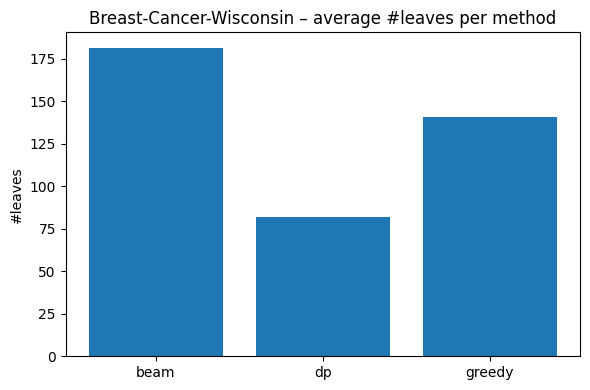

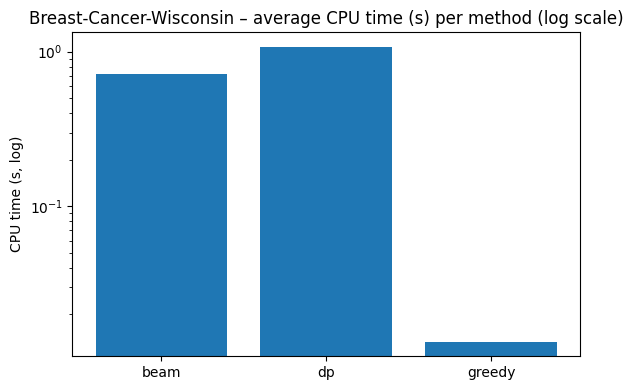

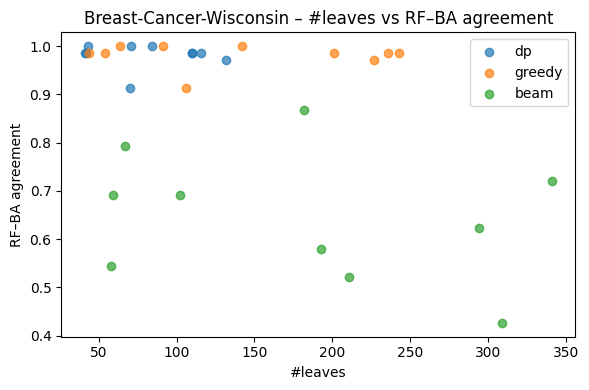

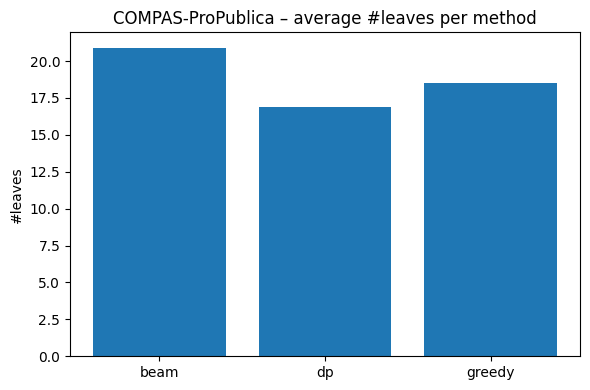

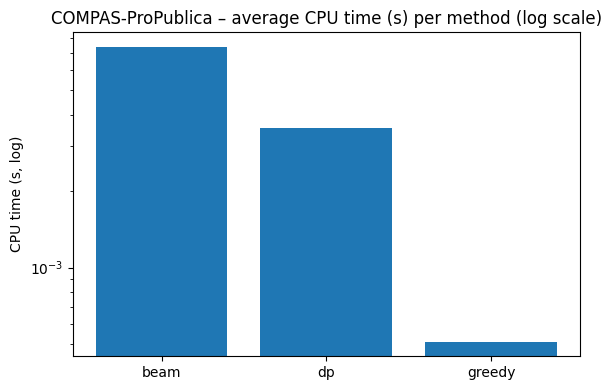

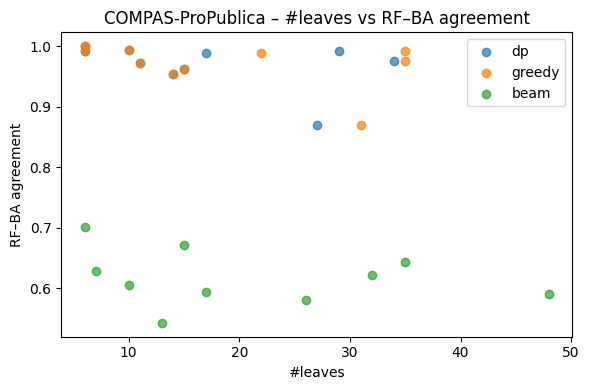

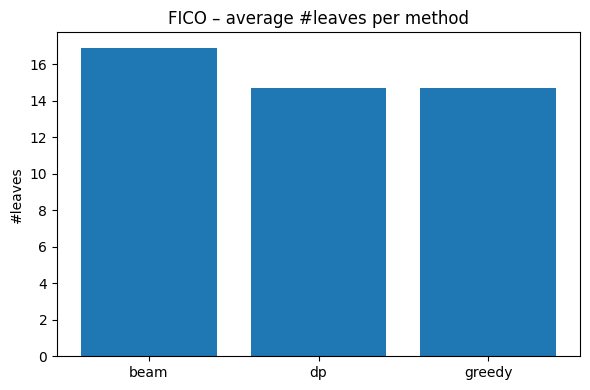

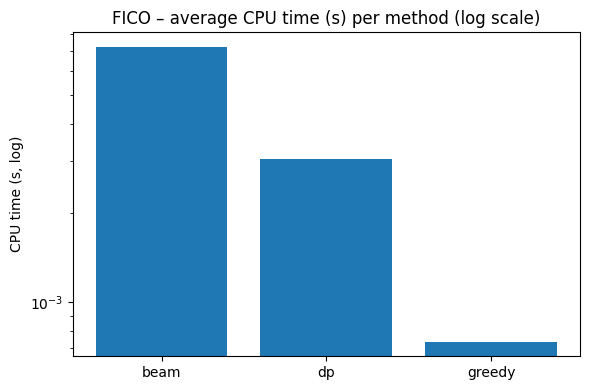

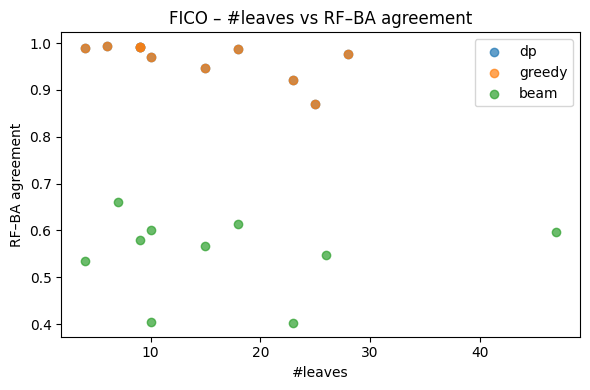

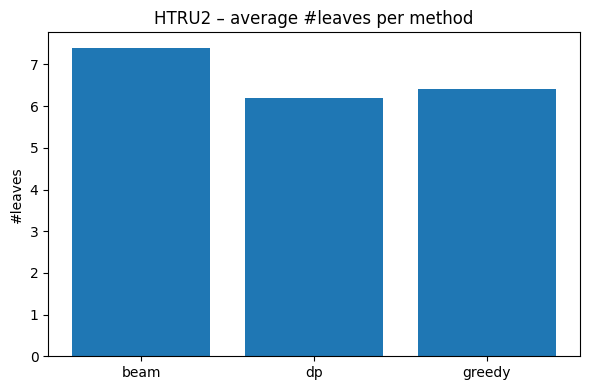

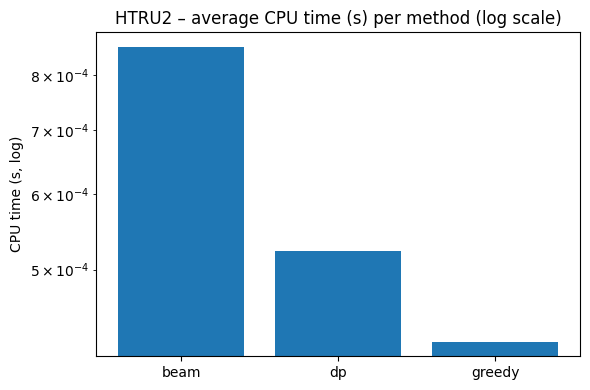

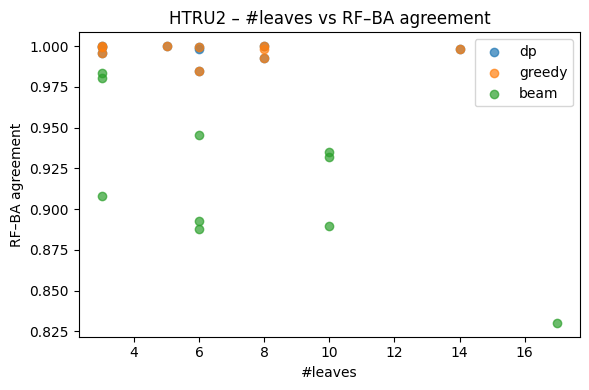

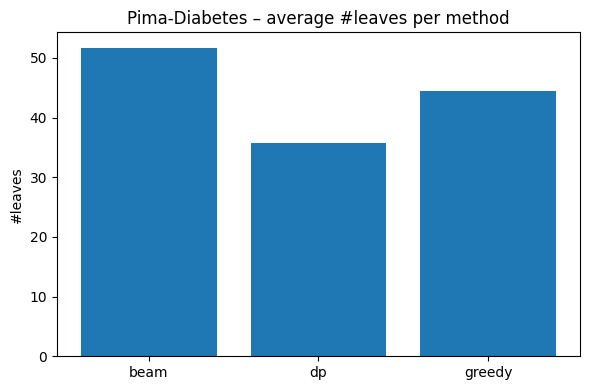

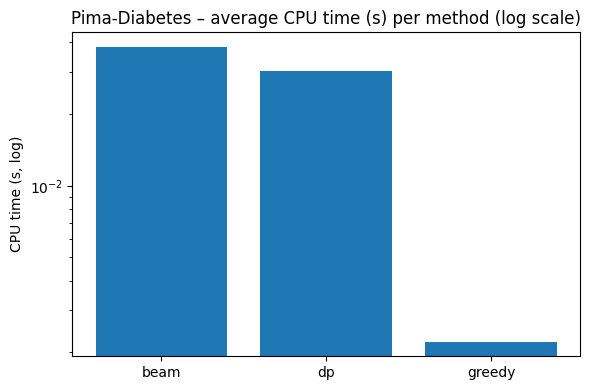

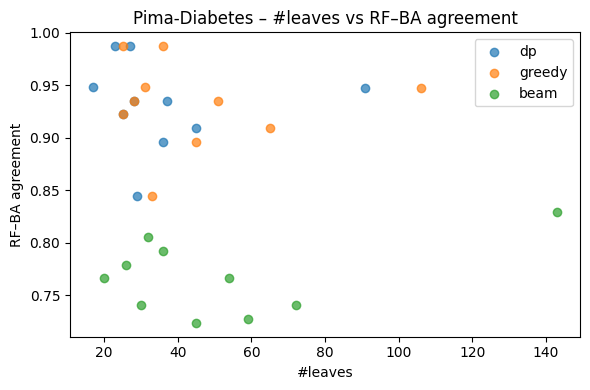

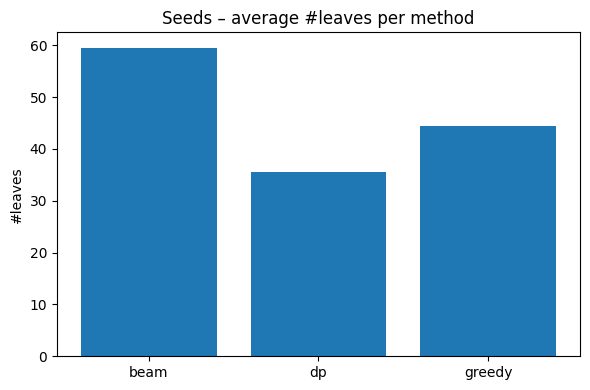

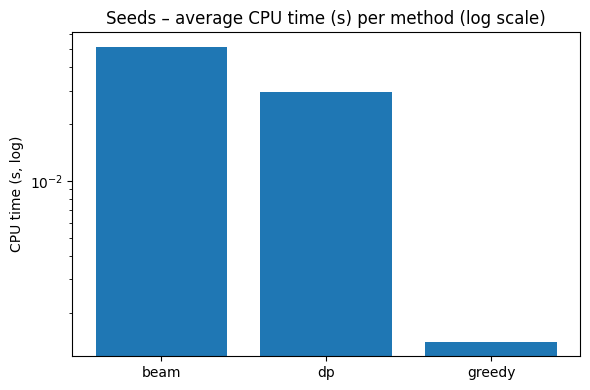

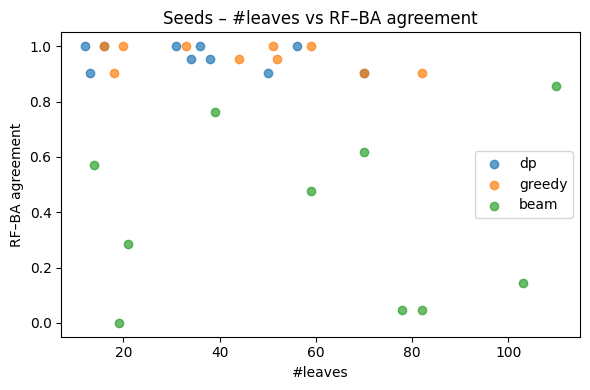

In [11]:
"""
Quick analysis script for BA-Trees experiments.

Usage (from project root, with .venv activated):

    python src/analyze_results.py

This will:
  - Load src/born_again_dp/results/summary.csv,
  - Print aggregate stats per dataset/method,
  - Show a few basic plots (one window per dataset).
"""

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ROOT = Path(__file__).resolve().parent.parent
# SUMMARY_PATH = ROOT / "src" / "born_again_dp" / "results" / "summary.csv"
SUMMARY_PATH = "born_again_dp/results/summary.csv"


def main():
    # if not SUMMARY_PATH.exists():
    #     raise SystemExit(f"summary.csv not found at {SUMMARY_PATH}. Run src/run_experiments.py first.")

    df = pd.read_csv(SUMMARY_PATH)
    print(f"Loaded {len(df)} rows from {SUMMARY_PATH}")

    # Aggregate per dataset/method
    agg = (
        df.groupby(["dataset", "method"])[
            ["depth", "leaves", "cpu_time", "rf_acc", "ba_acc", "rf_ba_agreement"]
        ]
        .mean()
        .reset_index()
    )
    print("\nAverage metrics per dataset/method:")
    print(agg.to_string(index=False))

    # Simple plots per dataset
    for dataset in df["dataset"].unique():
        sub = df[df["dataset"] == dataset]
        means = (
            sub.groupby("method")[["leaves", "cpu_time", "rf_ba_agreement"]]
            .mean()
            .reset_index()
        )

        # Bar plot: avg #leaves per method
        plt.figure(figsize=(6, 4))
        plt.bar(means["method"], means["leaves"])
        plt.title(f"{dataset} – average #leaves per method")
        plt.ylabel("#leaves")
        plt.tight_layout()
        plt.show()

        # Bar plot: avg CPU time per method (log scale)
        plt.figure(figsize=(6, 4))
        plt.bar(means["method"], means["cpu_time"])
        plt.yscale("log")
        plt.title(f"{dataset} – average CPU time (s) per method (log scale)")
        plt.ylabel("CPU time (s, log)")
        plt.tight_layout()
        plt.show()

        # Scatter: leaves vs RF–BA agreement
        plt.figure(figsize=(6, 4))
        for method in ["dp", "greedy", "beam"]:
            msub = sub[sub["method"] == method]
            plt.scatter(
                msub["leaves"],
                msub["rf_ba_agreement"],
                label=method,
                alpha=0.7,
            )
        plt.title(f"{dataset} – #leaves vs RF–BA agreement")
        plt.xlabel("#leaves")
        plt.ylabel("RF–BA agreement")
        plt.legend()
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    main()



## How to Read These Results

- **Average metrics table** — For each dataset and method, compare **depth** and **leaves** (smaller = more interpretable), **cpu_time** (Greedy/Beam are usually much faster than DP), and **rf_ba_agreement** (higher = BA-tree matches the RF more often on the test set). **ba_acc** vs **rf_acc** shows whether the single tree keeps or loses the RF’s accuracy.
- **Bar plots (leaves and CPU time)** — DP typically yields the smallest trees but can be slow; Greedy often matches DP in leaves on “easy” datasets at a fraction of the time; Beam may produce larger trees and vary more across folds.
- **Scatter (leaves vs RF–BA agreement)** — Generally, more leaves allow higher agreement. If a method gives many leaves but still low agreement, the dataset may be hard to capture with one tree, or the method may be exploring the wrong part of the solution space.

Comparing across **Breast-Cancer-Wisconsin**, **COMPAS-ProPublica**, **FICO**, **HTRU2**, **Pima-Diabetes**, and **Seeds** shows where DP is worth the extra time, where Greedy is sufficient, and where no single tree can faithfully replace the RF.

## Detailed Interpretation of Results

### Overall pattern: DP vs Greedy vs Beam

Across all six datasets, a clear pattern holds:

- **DP and Greedy** often produce the **same or very similar trees**: same number of leaves, same RF–BA agreement, and same BA accuracy. When they differ, DP always has fewer (or equal) leaves (it is optimal), while Greedy can use more leaves. Greedy is **orders of magnitude faster** (milliseconds vs seconds on harder instances).
- **Beam** consistently yields **larger trees** (more leaves) and **lower RF–BA agreement** than DP and Greedy. On some folds it is much worse, so it is not a reliable substitute when the goal is a small, faithful tree.

So in practice: **use Greedy** when you want a small, faithful BA-tree quickly; use **DP** when you need a guarantee of minimum leaves and can afford the runtime. **Beam** is not recommended for minimizing tree size or maximizing agreement.

---

### Dataset-by-dataset summary

**Breast-Cancer-Wisconsin**  
- DP finds trees with roughly 40–130 leaves depending on fold; Greedy often matches it, sometimes produces 2–3× more leaves (e.g. fold 2: 110 vs 243). Agreement for DP/Greedy is high (≈91–100%). Beam produces 57–341 leaves and agreement drops to ≈42–87%, with much higher CPU time. The problem is “medium”: small enough that DP is tractable, but fold-to-fold variance in tree size is large.

**COMPAS-ProPublica**  
- DP and Greedy **coincide on every fold** (same depth, same leaves, same agreement). Trees are small (e.g. 5–9 depth, 6–35 leaves). Agreement is high (≈87–99%). Beam uses more leaves and achieves only ≈52–67% agreement. For this fairness-related dataset, DP or Greedy both give a single, interpretable tree that closely matches the RF; Beam would be a poor choice.

**FICO**  
- Again **DP and Greedy match** on every fold (same tree). Trees are small (depth 3–8, 4–28 leaves). RF–BA agreement is high (≈87–99%), and BA accuracy is close to RF accuracy. Beam has lower agreement (≈40–66%) and does not improve tree size. For explainability in credit scoring, DP or Greedy are equivalent and preferable.

**HTRU2**  
- Easiest dataset: very small trees (depth 2–7, 3–14 leaves), and DP/Greedy match. Agreement is very high (≈98–100%). Beam produces slightly larger trees and agreement drops to ≈89–98%. All methods are fast; the RF is well-approximable by one tree.

**Pima-Diabetes**  
- DP and Greedy are close: same or similar agreement (≈84–99%); Greedy sometimes has a few more leaves (e.g. 45 vs 36, 51 vs 37). Beam again has more leaves and lower agreement (≈72–83%). So again, Greedy is a good default; DP if you need a size guarantee.

**Seeds**  
- DP and Greedy behave similarly and achieve high agreement (≈90–100%). **Beam fails badly on several folds**: e.g. folds 5, 6, 8, 9, 10 show RF–BA agreement as low as 0–57% and sometimes 0% BA accuracy, despite using many leaves. This illustrates that Beam can produce trees that neither minimize size nor match the RF—useful as a cautionary example when choosing methods.

---

### Takeaways

1. **Greedy is a strong default**: it often matches DP in tree size and agreement at a fraction of the runtime; when it doesn’t, the extra leaves are usually modest.
2. **DP is worth it** when you need a provably minimal tree and the instance is small enough (e.g. Breast-Cancer, Pima); on the largest folds, CPU time grows (e.g. several seconds).
3. **Beam is not recommended** for “small, faithful” BA-trees: it tends to larger trees and lower agreement, and can fail badly (e.g. Seeds).
4. **Dataset difficulty** varies: HTRU2 and FICO/COMPAS are easy (small trees, high agreement); Breast-Cancer and Pima show more variance and larger trees; Seeds is easy for DP/Greedy but problematic for Beam.
5. **Interpretability vs fidelity**: On all datasets where DP/Greedy do well, the single BA-tree preserves most of the RF’s predictions (high agreement) and similar test accuracy, so the trade-off is favorable for interpretability.